In [41]:
import pandas as pd
import random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
np.random.seed(42)
random.seed(42)

In [5]:
num_students=60

In [23]:
data = {
    "student_id":range(1,num_students+1),
    "name":[f"Student_{i}" for i in range(1,num_students+1)],
    "gender":np.random.choice(["Male","Female"],num_students),
    "age":np.random.randint(18,25,num_students),
    "class" : np.random.choice(['FY','SY','TY'],num_students),
    "maths":np.random.randint(35,100,num_students),
    "physics":np.random.randint(30,100,num_students),
    "chemistry":np.random.randint(40,100,num_students),
    "attendance":np.random.randint(60,100,num_students),
    "study_hours":np.random.randint(4,8,num_students)
}

In [51]:
for col in ['gender','age','class','maths','physics','chemistry']:
    df.loc[df.sample(frac=0.8).index,col]=np.nan

In [ ]:
outliers = np.random.choice(df.index,size=3)

df.loc[outliers,study_hours] = [60,65,100]

In [ ]:
df = pd.DataFrame(data)

In [26]:
print(df.head())

   student_id       name  gender  age class  maths  physics  chemistry  \
0           1  Student_1  Female   22    TY     77       40         95   
1           2  Student_2  Female   19    SY     49       79         48   
2           3  Student_3  Female   20    SY     94       60         80   
3           4  Student_4    Male   19    SY     46       85         40   
4           5  Student_5    Male   23    FY     83       38         41   

   attendance  study_hours  
0          74            6  
1          78            6  
2          66            4  
3          87            7  
4          64            4  


In [27]:
print(df.shape)

(60, 10)


In [28]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   student_id   60 non-null     int64 
 1   name         60 non-null     object
 2   gender       60 non-null     object
 3   age          60 non-null     int32 
 4   class        60 non-null     object
 5   maths        60 non-null     int32 
 6   physics      60 non-null     int32 
 7   chemistry    60 non-null     int32 
 8   attendance   60 non-null     int32 
 9   study_hours  60 non-null     int32 
dtypes: int32(6), int64(1), object(3)
memory usage: 3.4+ KB
None


In [37]:
print(df.isnull().sum())

student_id     0
name           0
gender         0
age            0
class          0
maths          0
physics        0
chemistry      0
attendance     0
study_hours    0
dtype: int64


In [32]:
df = df.fillna(df.mean(numeric_only=True))

In [34]:
print(df.head())

   student_id       name  gender        age class      maths    physics  \
0           1  Student_1     NaN  22.000000   NaN  77.000000  69.666667   
1           2  Student_2     NaN  20.583333   NaN  56.916667  69.666667   
2           3  Student_3  Female  20.000000   NaN  56.916667  69.666667   
3           4  Student_4    Male  19.000000   NaN  56.916667  69.666667   
4           5  Student_5    Male  20.583333   NaN  56.916667  69.666667   

   chemistry  attendance  study_hours  
0  68.166667          74            6  
1  48.000000          78            6  
2  68.166667          66            4  
3  40.000000          87            7  
4  68.166667          64            4  


In [36]:
df.dropna(subset=['gender','class'],inplace=True)

In [39]:
df['gender']= df['gender'].map({
    'Female':0,
    'Male':1
})
   

In [40]:
print(df['gender'])

19    1
54    0
Name: gender, dtype: int64


<Axes: xlabel='maths', ylabel='Count'>

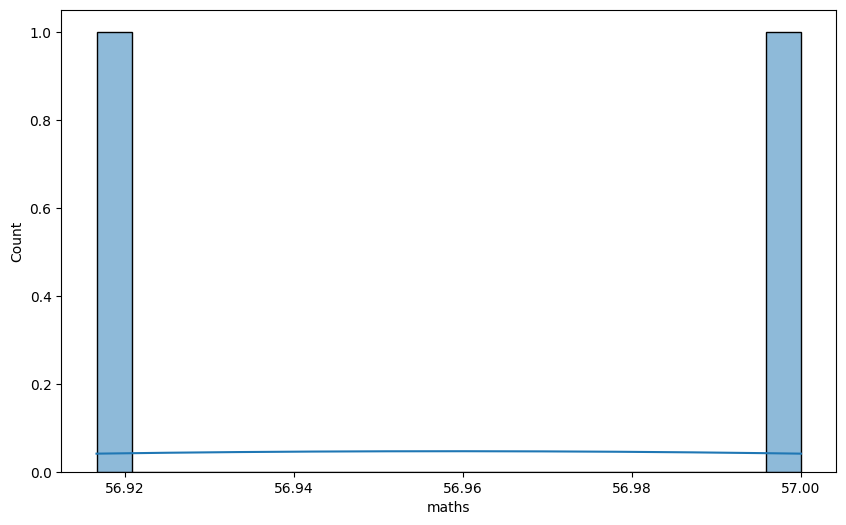

In [45]:
plt.figure(figsize=(10,6))

sns.histplot(df['maths'],bins=20,kde=True)

<Axes: ylabel='study_hours'>

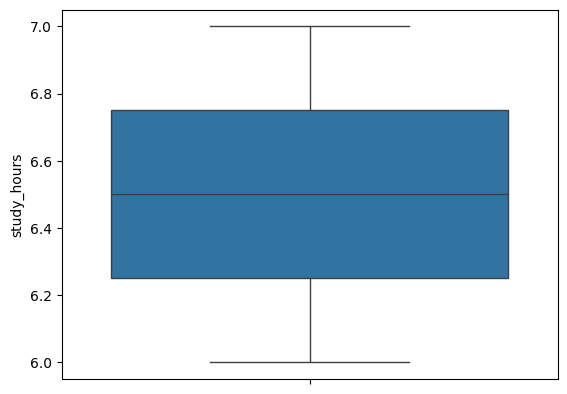

In [48]:
sns.boxplot(y=df['study_hours'])